In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tcn import TCN
import os

In [2]:
overview_data = pd.read_excel("data\\0list.xlsx")

In [4]:
X = []
y = []

for idx, row in overview_data.iterrows():
    patient_num = row['Patient']
    disease_type = int(row['Score (type)'])

    healthy_file = pd.read_csv(f'data/Resultados/Elastome_{int(patient_num):04d}_Healthy_angle_1.csv')
    patho_file = pd.read_csv(f'data/Resultados/Elastome_{int(patient_num):04d}_Patho_angle_1.csv')

    X.append(healthy_file.values)
    y.append(6)
    X.append(patho_file.values)
    y.append(disease_type)


In [5]:
max_len = max([x.shape[0] for x in X])
X_padded = []
for x in X:
    pad_len = max_len - x.shape[0]
    if pad_len > 0:
        padding = np.zeros((pad_len, x.shape[1]))
        x_padded = np.vstack([x, padding])
    else:
        x_padded = x[:max_len, :]
    X_padded.append(x_padded)
X_padded = np.array(X_padded)

# Encode labels
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Normalize features across all samples and timesteps
X_reshaped = X_padded.reshape(-1, X_padded.shape[-1])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reshaped).reshape(X_padded.shape)

d:\Anaconda\envs\epf\Lib\site-packages\sklearn\utils\extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\utils\extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\utils\extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
X = np.array(X_scaled)
y = np.array(y_categorical)

if np.isnan(X).any():
    nan_mask = np.isnan(X).any(axis=(0,1)) 
    X = X[:, :, ~nan_mask]
    print(f"Dropped {nan_mask.sum()} features with NaN values")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Dropped 11 features with NaN values


In [16]:
num_classes = y_categorical.shape[1]
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    TCN(nb_filters=32, kernel_size=3, dilations=[1,2,4,8], dropout_rate=0.2),
    Dense(num_classes, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=30, batch_size=16)

Epoch 1/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 475ms/step - accuracy: 0.1875 - loss: 2.7339 - val_accuracy: 0.3750 - val_loss: 1.8515
Epoch 2/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.1875 - loss: 2.3868 - val_accuracy: 0.5000 - val_loss: 1.8101
Epoch 3/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3125 - loss: 2.3515 - val_accuracy: 0.5000 - val_loss: 1.7795
Epoch 4/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.3438 - loss: 1.8513 - val_accuracy: 0.5000 - val_loss: 1.7553
Epoch 5/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.3125 - loss: 2.2612 - val_accuracy: 0.5000 - val_loss: 1.7349
Epoch 6/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.4688 - loss: 2.0386 - val_accuracy: 0.5000 - val_loss: 1.7299
Epoch 7/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.4688 - loss: 1.7212 - val_accuracy: 0.5000 - val_loss: 1.7322
Epoch 8/30
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.4688 - loss: 1.9364 - val_accuracy: 0.5000 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step


d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
d:\Anaconda\envs\epf\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


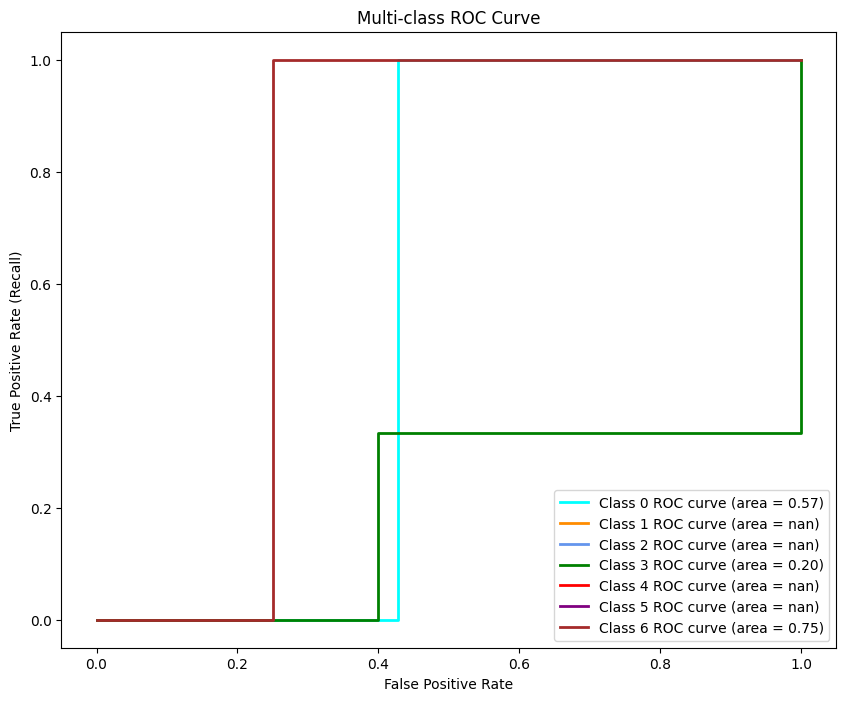

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from itertools import cycle

y_score = model.predict(X_val)

y_true = y_val 

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple', 'brown'])
for i, color in zip(range(num_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {i} ROC curve (area = {roc_auc[i]:.2f})')


plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Multi-class ROC Curve')
plt.legend(loc="lower right")
plt.show()
